# Business answers

In [1]:
import duckdb
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "png"

con = duckdb.connect('../warehouse.duckdb', read_only=True)

surface = "#fcfcfb"
ink_primary = "#0b0b0b"
ink_secondary = "#52514e"
ink_muted = "#898781"
gridline = "#e1e0d9"
baseline = "#c3c2b7"
blue = "#2a78d6"
orange = "#eb6834"

font = dict(family="Segoe UI, -apple-system, system-ui, sans-serif", color=ink_primary, size=13)

template = go.layout.Template()
template.layout = go.Layout(
    paper_bgcolor=surface,
    plot_bgcolor=surface,
    font=font,
    xaxis=dict(gridcolor=gridline, linecolor=baseline, zerolinecolor=baseline, tickfont=dict(color=ink_muted), automargin=True),
    yaxis=dict(gridcolor=gridline, linecolor=baseline, zerolinecolor=baseline, tickfont=dict(color=ink_muted), automargin=True),
    margin=dict(l=20, r=60, t=50, b=40),
)


## 1. Top 10 products by revenue

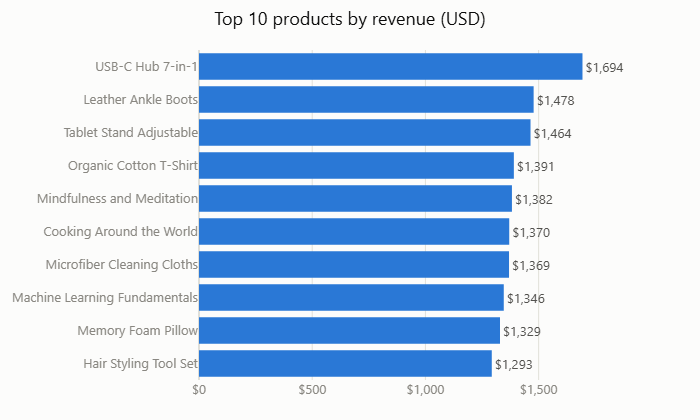

In [2]:
revenue_df = con.execute('''
    select product_name, total_revenue_usd
    from main.rpt_product_performance
    order by total_revenue_usd desc
    limit 10
''').df()
revenue_df = revenue_df.sort_values('total_revenue_usd')

fig = go.Figure(go.Bar(
    x=revenue_df['total_revenue_usd'],
    y=revenue_df['product_name'],
    orientation='h',
    marker_color=blue,
    text=[f"${v:,.0f}" for v in revenue_df['total_revenue_usd']],
    textposition='outside',
    textfont=dict(color=ink_secondary),
))
fig.update_layout(template=template, title="Top 10 products by revenue (USD)", height=420)
fig.update_xaxes(title=None, tickprefix="$", separatethousands=True, range=[0, revenue_df['total_revenue_usd'].max() * 1.15])
fig.show()


## 2. Top 10 products by volume

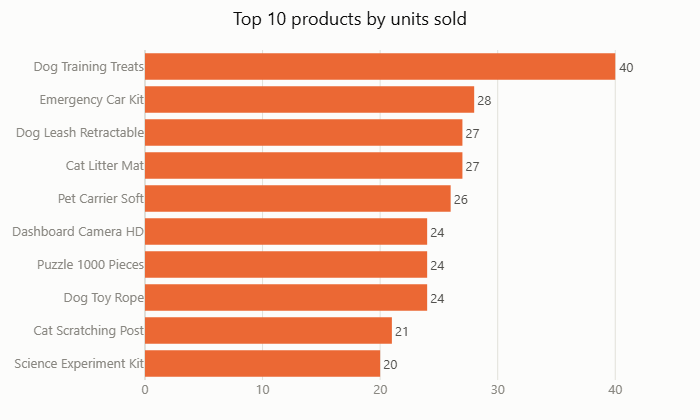

In [3]:
volume_df = con.execute('''
    select product_name, total_quantity
    from main.rpt_product_performance
    order by total_quantity desc
    limit 10
''').df()
volume_df = volume_df.sort_values('total_quantity')

fig = go.Figure(go.Bar(
    x=volume_df['total_quantity'],
    y=volume_df['product_name'],
    orientation='h',
    marker_color=orange,
    text=[f"{int(v)}" for v in volume_df['total_quantity']],
    textposition='outside',
    textfont=dict(color=ink_secondary),
))
fig.update_layout(template=template, title="Top 10 products by units sold", height=420)
fig.update_xaxes(title=None, separatethousands=True)
fig.show()


## 3. Orders by hour of day

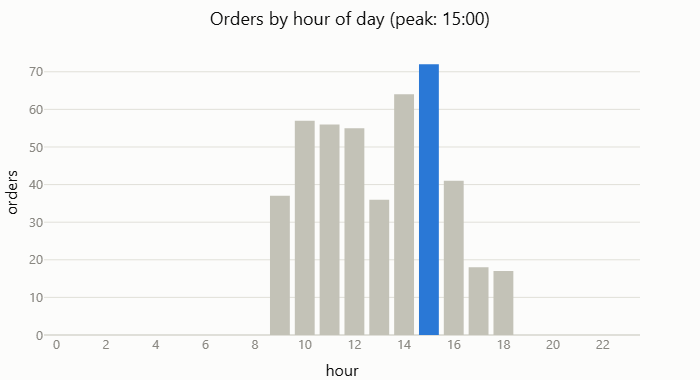

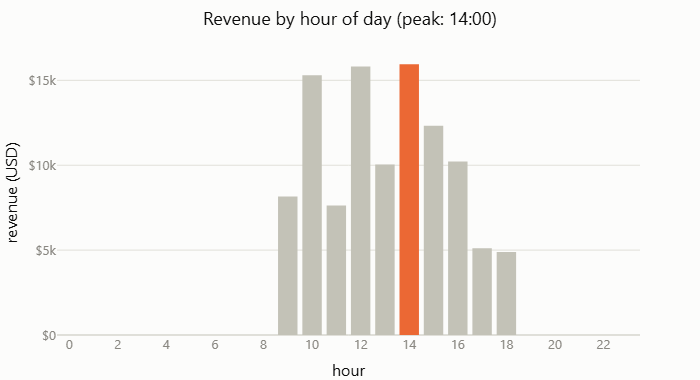

In [4]:
import pandas as pd

hourly_df = con.execute('''
    select order_hour, order_count, total_revenue_usd
    from main.rpt_promo_timing
    order by order_hour
''').df()
hourly_df = hourly_df.set_index('order_hour').reindex(range(24), fill_value=0).reset_index()

peak_order_hour = hourly_df.loc[hourly_df['order_count'].idxmax(), 'order_hour']
colors = [blue if h == peak_order_hour else baseline for h in hourly_df['order_hour']]

fig = go.Figure(go.Bar(
    x=hourly_df['order_hour'],
    y=hourly_df['order_count'],
    marker_color=colors,
))
fig.update_layout(template=template, title=f"Orders by hour of day (peak: {peak_order_hour}:00)", height=380)
fig.update_xaxes(title="hour", dtick=2)
fig.update_yaxes(title="orders")
fig.show()

peak_revenue_hour = hourly_df.loc[hourly_df['total_revenue_usd'].idxmax(), 'order_hour']
colors = [orange if h == peak_revenue_hour else baseline for h in hourly_df['order_hour']]

fig = go.Figure(go.Bar(
    x=hourly_df['order_hour'],
    y=hourly_df['total_revenue_usd'],
    marker_color=colors,
))
fig.update_layout(template=template, title=f"Revenue by hour of day (peak: {peak_revenue_hour}:00)", height=380)
fig.update_xaxes(title="hour", dtick=2)
fig.update_yaxes(title="revenue (USD)", tickprefix="$", separatethousands=True)
fig.show()


## 4. Item coverage

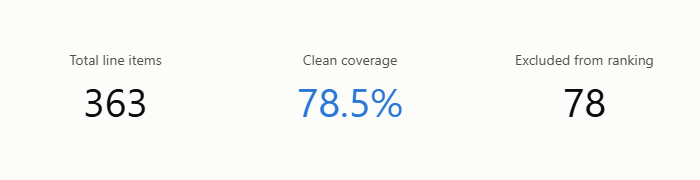

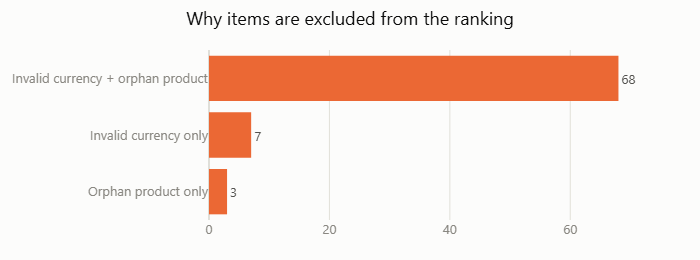

In [5]:
coverage_df = con.execute('''
    select
        case
            when is_valid_currency_code and not is_product_id_orphan then 'Clean'
            when not is_valid_currency_code and is_product_id_orphan then 'Invalid currency + orphan product'
            when not is_valid_currency_code then 'Invalid currency only'
            else 'Orphan product only'
        end as status,
        count(*) as n
    from main.fct_order_items
    group by 1
''').df()

total_items = coverage_df['n'].sum()
clean_items = coverage_df.loc[coverage_df['status'] == 'Clean', 'n'].sum()
excluded_items = total_items - clean_items

fig = go.Figure()
fig.add_trace(go.Indicator(
    mode="number",
    value=total_items,
    title={"text": "Total line items", "font": {"size": 14, "color": ink_secondary}},
    number={"font": {"size": 40, "color": ink_primary}},
    domain={"row": 0, "column": 0},
))
fig.add_trace(go.Indicator(
    mode="number",
    value=clean_items / total_items * 100,
    number={"suffix": "%", "font": {"size": 40, "color": blue}},
    title={"text": "Clean coverage", "font": {"size": 14, "color": ink_secondary}},
    domain={"row": 0, "column": 1},
))
fig.add_trace(go.Indicator(
    mode="number",
    value=excluded_items,
    number={"font": {"size": 40, "color": ink_primary}},
    title={"text": "Excluded from ranking", "font": {"size": 14, "color": ink_secondary}},
    domain={"row": 0, "column": 2},
))
fig.update_layout(
    template=template,
    grid={"rows": 1, "columns": 3},
    height=180,
    margin=dict(l=10, r=10, t=30, b=10),
)
fig.show()

breakdown_df = coverage_df[coverage_df['status'] != 'Clean'].sort_values('n')
fig = go.Figure(go.Bar(
    x=breakdown_df['n'],
    y=breakdown_df['status'],
    orientation='h',
    marker_color=orange,
    text=breakdown_df['n'],
    textposition='outside',
    textfont=dict(color=ink_secondary),
))
fig.update_layout(template=template, title="Why items are excluded from the ranking", height=260)
fig.update_xaxes(title=None)
fig.show()
